In [1]:
###################################
## using conda env neuron_branching 
## to processing Stephan's neuron images to character the tree topology 
###################################

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import copy

In [3]:
from skimage.io import imread
from skimage.io import imsave
from skimage import filters
from skimage import morphology
from skimage import measure

In [4]:
import napari
from napari.utils import nbscreenshot
from pyclesperanto_prototype import imshow
import pyclesperanto_prototype as cle
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [5]:
cle.available_device_names()
# For 3D processing, powerful graphics
# processing units might be necessary
cle.select_device('TX')

/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/pyclesperanto_prototype/_tier0/_device.py:77: UserWarning: No OpenCL device found with TX in their name. Using Apple M1 Max instead.
  warnings.warn(f"No OpenCL device found with {name} in their name. Using {device.name} instead.")


<Apple M1 Max on Platform: Apple (2 refs)>

In [6]:
#import czifile
from aicsimageio import AICSImage
from aicsimageio.writers import OmeTiffWriter

In [7]:
inputDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/neuron_branching_test_Stephan"
#fileName = '2d-Right2-Stitching.czi'
#fileName = "Right4-Stitching.czi"
#fileName = "3d-Right4-Stitching.czi"
fileName = "2026.01.16_AMP_003_Right_Arm.czi"

path_results = 'results/' \
        + 'test_Stephan_nerves' + '/'
outDir = path_results

if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)

results/test_Stephan_nerves/


In [8]:
## read czi file (https://forum.image.sc/t/reading-czi-file-in-python/39768/3)
img = AICSImage(os.path.join(inputDir, fileName))

In [9]:
image = img.data #returns 6D STCZYX numpy array

In [10]:
print(image.shape)
print(img.dims)  # returns string "STCZYX"
print(img.shape)  # returns tuple of dimension sizes in STCZYX order

(1, 3, 182, 2048, 2048)
<Dimensions [T: 1, C: 3, Z: 182, Y: 2048, X: 2048]>
(1, 3, 182, 2048, 2048)


In [11]:
# Metadata Reading (https://allencellmodeling.github.io/aicsimageio/index.html)
img.channel_names  # returns a list of string channel names found in the metadata

[np.str_('AF647-T1'), np.str_('mCher-T2'), np.str_('EGFP-T3')]

In [12]:
print(img.physical_pixel_sizes.Z)  # returns the Z dimension pixel size as found in the metadata
print(img.physical_pixel_sizes.Y)  # returns the Y dimension pixel size as found in the metadata
print(img.physical_pixel_sizes.X)  # returns the X dimension pixel size as found in the metadata

2.01
0.690535481770833
0.690535481770833


In [13]:
AF647_c1 = img.get_image_data("ZYX", C=0, S=0, T=0)
mCher_c2 = img.get_image_data("ZYX", C=1, S=0, T=0)
EGFP_c3= img.get_image_data("ZYX", C=2, S=0, T=0)

In [15]:
np.max(EGFP_c3), np.max(mCher_c2), np.max(AF647_c1)

(np.uint8(255), np.uint8(255), np.uint8(255))

In [16]:
viewer = napari.Viewer()
viewer.add_image(AF647_c1)
viewer.add_image(mCher_c2)
viewer.add_image(EGFP_c3)

<Image layer 'EGFP_c3' at 0x3c90e6fd0>

In [16]:
imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_AF647_C1.tif")), AF647_c1)
imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_allNeurons_C2.tif")), mCher_c2)
imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_motorNeurons_C3.tif")), EGFP_c3)

In [9]:
################################# 
##import and check the new images from Stephan
#################################
import gc
inputDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/neuron_branching_test_Stephan/2026.04_Pmir218_Lightsheet_1wpi/downsampled"

fileName = "CTLS_Capture_E1_Pos_3_5_3DMontage_Complete_XY1775557583_Z000_T0"

outDir = 'results/' + 'test_Stephan_nerves' + '/'

if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)

results/test_Stephan_nerves/


In [9]:
c0 = imread(os.path.join(inputDir, str(fileName + "_C0_downsampled_3fold.tif")))

In [10]:
viewer = napari.Viewer()
viewer.add_image(c0)

Assistant skips harvesting pyclesperanto as it's not installed.


<Image layer 'c0' at 0x106c7fa30>

/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/napari/_vispy/layers/scalar_field.py:198: UserWarning: data shape (699, 3748, 2462) exceeds GL_MAX_TEXTURE_SIZE 2048 in at least one axis and will be downsampled. Rendering is currently in 3D mode.
  warnings.warn(


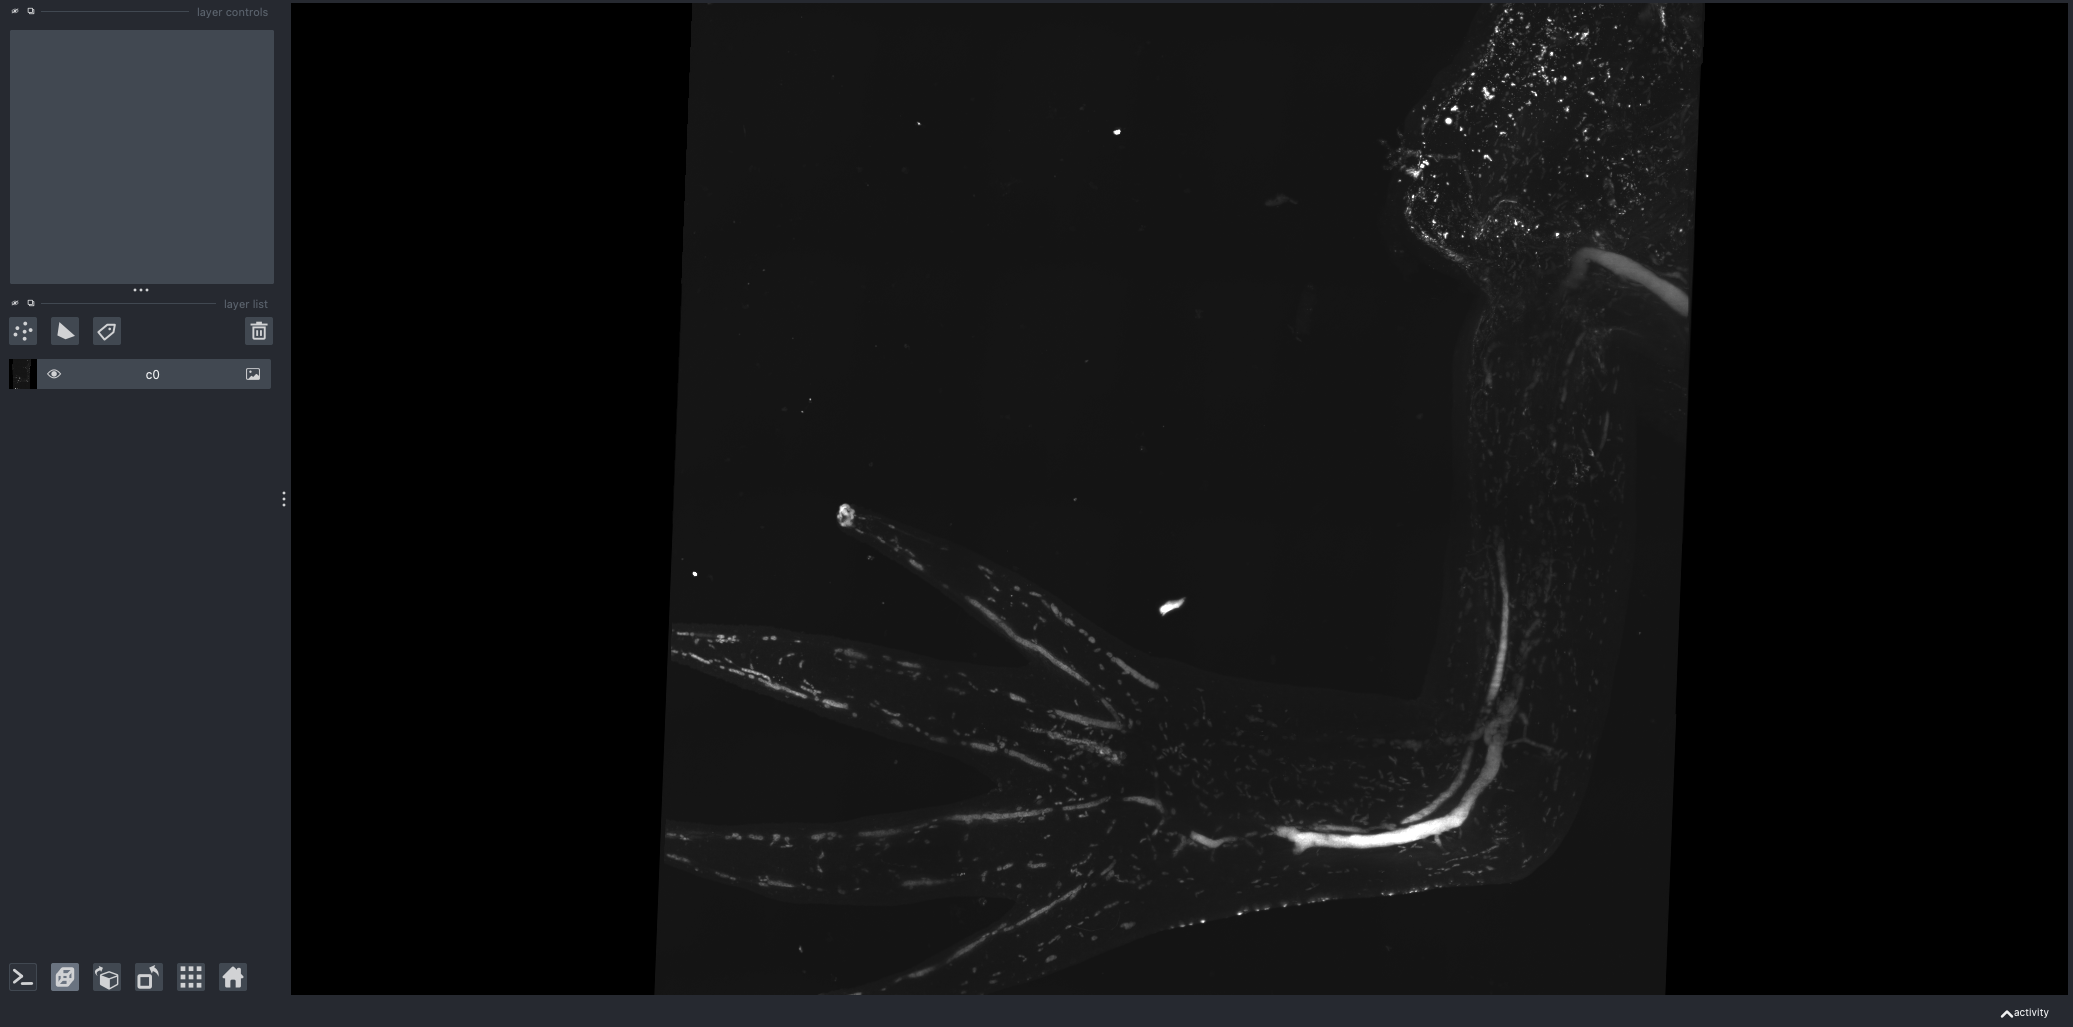

In [11]:
nbscreenshot(viewer)

In [13]:
c0 = None; gc.collect();

In [11]:
image = imread(os.path.join(inputDir, str(fileName + "_C1_downsampled_3fold.tif")))

In [12]:
viewer = napari.Viewer()
viewer.add_image(image)

Assistant skips harvesting pyclesperanto as it's not installed.


<Image layer 'image' at 0x104a27e80>

/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/napari/_vispy/layers/scalar_field.py:198: UserWarning: data shape (699, 3748, 2462) exceeds GL_MAX_TEXTURE_SIZE 2048 in at least one axis and will be downsampled. Rendering is currently in 3D mode.
  warnings.warn(


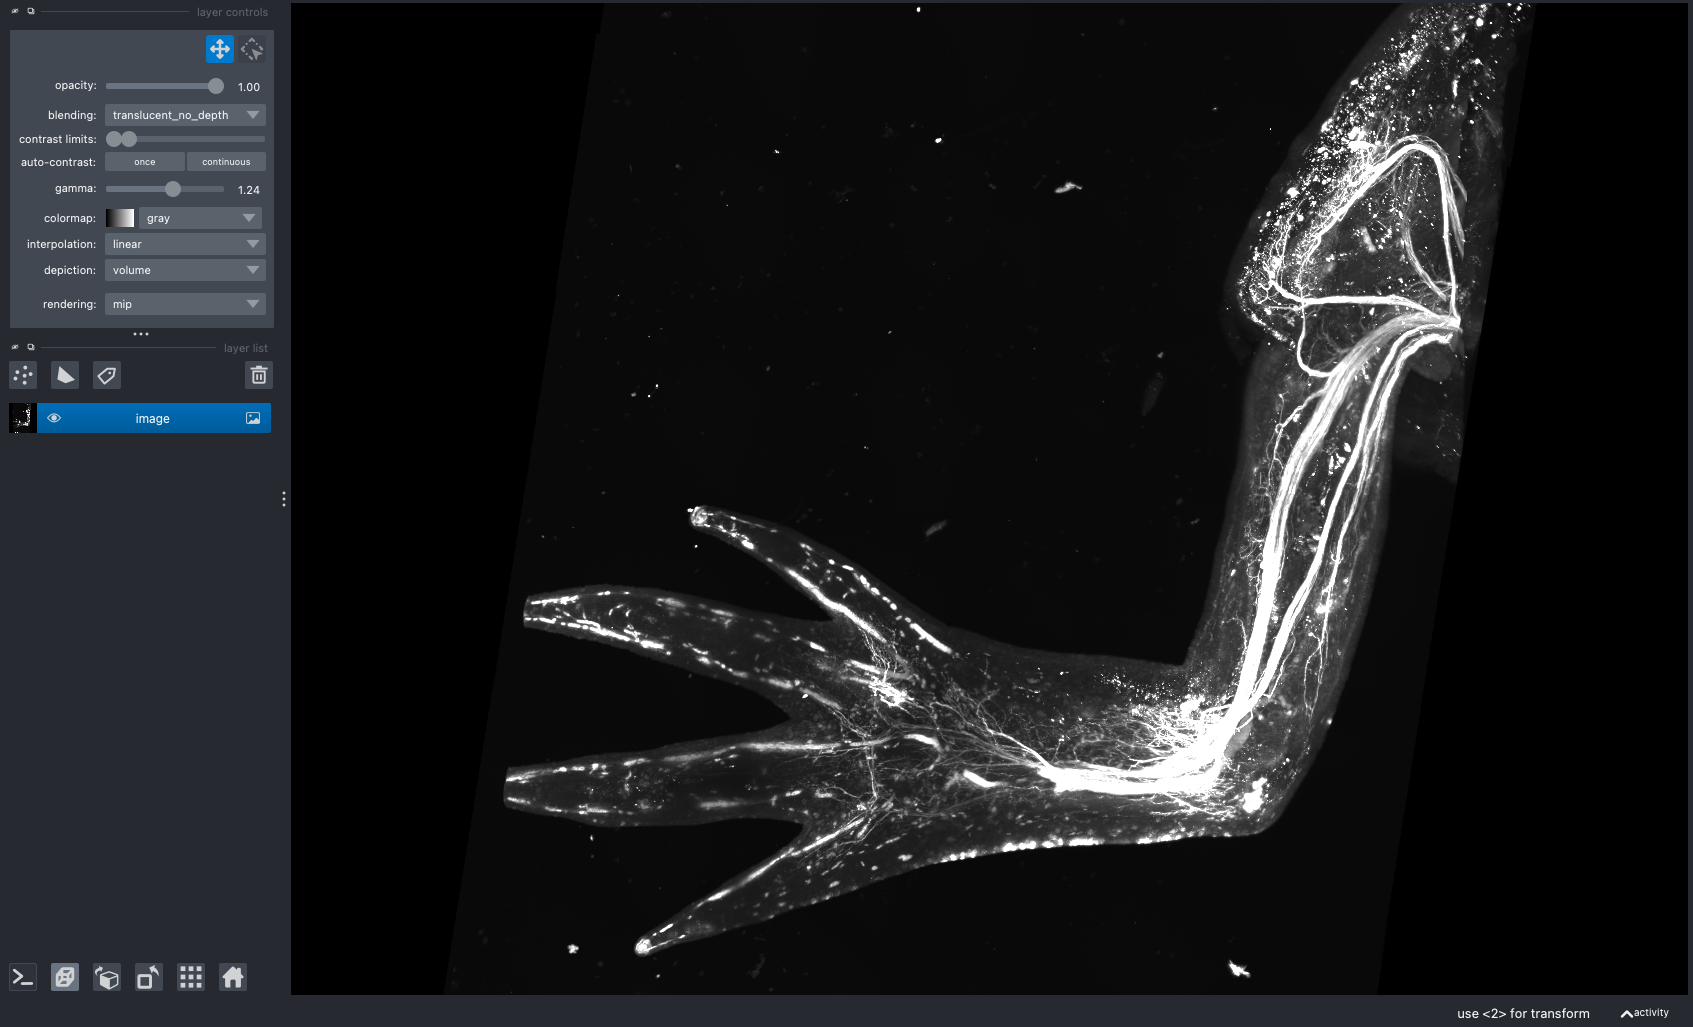

In [13]:
nbscreenshot(viewer)

In [ ]:
c0 = None; gc.collect();

In [9]:
image = imread(os.path.join(inputDir, str(fileName + "_C2_downsampled_3fold.tif")))

In [10]:
viewer = napari.Viewer()
viewer.add_image(image)

Assistant skips harvesting pyclesperanto as it's not installed.


<Image layer 'image' at 0x10870c190>

/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/napari/_vispy/layers/scalar_field.py:198: UserWarning: data shape (699, 3748, 2462) exceeds GL_MAX_TEXTURE_SIZE 2048 in at least one axis and will be downsampled. Rendering is currently in 3D mode.
  warnings.warn(


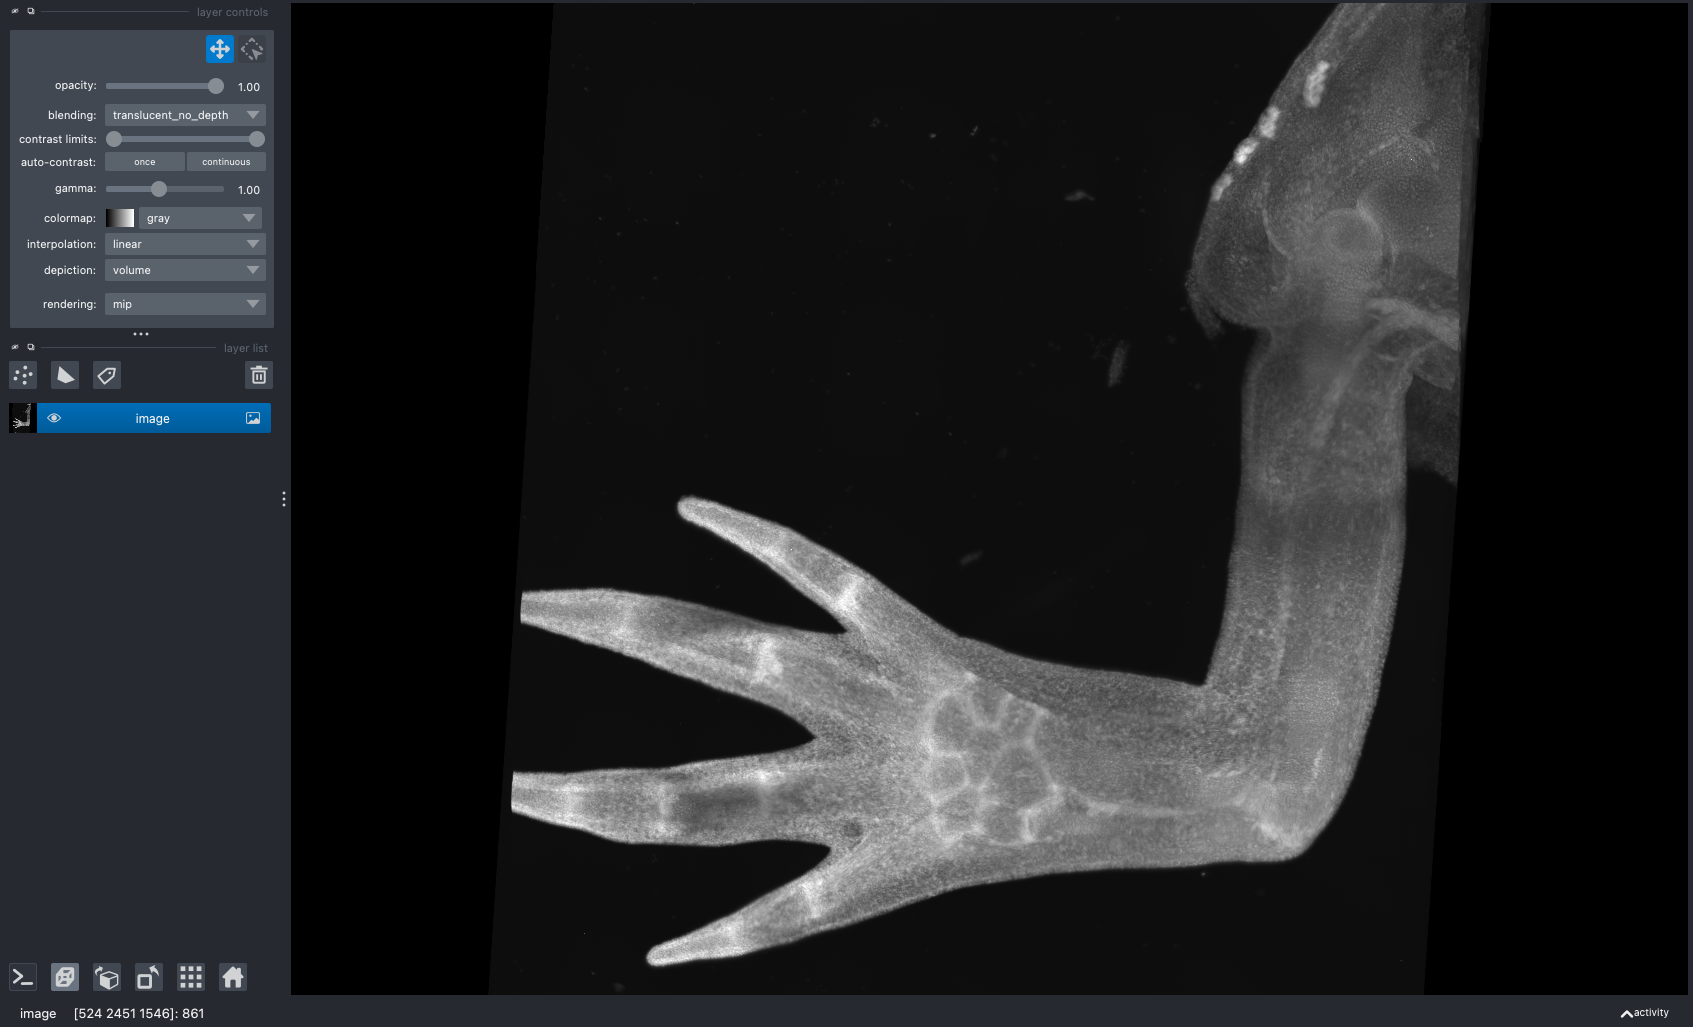

In [11]:
nbscreenshot(viewer)

In [8]:
################################# 
## processing C1 motor neurons and try to reduce the image size
#################################
import gc
inputDir = "/Users/jingkui.wang/workspace/imp/image_analysis_test/results/test_Stephan_nerves"

fileName = "CTLS_Capture_E1_Pos_3_5_3DMontage_Complete_XY1775557583_Z000_T0"

outDir = 'results/' + 'test_Stephan_nerves' + '/'

if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)
#CTLS_Capture_E1_Pos_3_5_3DMontage_Complete_XY1775557583_Z000_T0_C1_downsampled_4fold.tif

results/test_Stephan_nerves/


In [9]:
inputDir, fileName

('/Users/jingkui.wang/workspace/imp/image_analysis_test/results/test_Stephan_nerves',
 'CTLS_Capture_E1_Pos_3_5_3DMontage_Complete_XY1775557583_Z000_T0')

In [10]:
neuron = imread(os.path.join(inputDir, str(fileName + "_C1_downsampled_4fold.tif")))

In [11]:
neuron.shape, neuron.dtype

((699, 2811, 1847), dtype('float64'))

In [12]:
np.max(neuron), np.min(neuron)

(np.float64(65535.0), np.float64(0.0))

In [13]:
from skimage import (exposure, feature, filters, io, measure,
                      morphology, restoration, segmentation, transform,
                      util)
neuron_downsample = transform.downscale_local_mean(neuron, factors=(2, 1, 1))

In [14]:
neuron_downsample.shape, 

(350, 2811, 1847)

In [26]:
#from skimage import img_as_ubyte
#img_uint8 = img_as_ubyte(neuron)

In [16]:
neuron.dtype, neuron_downsample.dtype, np.max(neuron_downsample), np.min(neuron_downsample)

(dtype('float64'), dtype('float64'), np.float64(65535.0), np.float64(0.0))

In [17]:
from skimage import exposure
img_uint8 = exposure.rescale_intensity(
    neuron_downsample,
    in_range='image',
    out_range=(0, 255)
).astype(np.uint8)

In [18]:
img_uint8.shape, np.max(img_uint8), np.min(img_uint8)

((350, 2811, 1847), np.uint8(255), np.uint8(0))

In [25]:
viewer = napari.Viewer()
viewer.add_image(img_uint8)

Assistant skips harvesting pyclesperanto as it's not installed.


<Image layer 'img_uint8' at 0xac8bb9550>

/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/napari/_vispy/layers/scalar_field.py:198: UserWarning: data shape (699, 2811, 1847) exceeds GL_MAX_TEXTURE_SIZE 2048 in at least one axis and will be downsampled. Rendering is currently in 3D mode.
  warnings.warn(


In [19]:
imsave(os.path.join(outDir, str(fileName + "_motorNeurons_downsampled8fold_uint8.tif")), img_uint8)

/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_27240/773726610.py:1: UserWarning: results/test_Stephan_nerves/CTLS_Capture_E1_Pos_3_5_3DMontage_Complete_XY1775557583_Z000_T0_motorNeurons_downsampled8fold_uint8.tif is a low contrast image
  imsave(os.path.join(outDir, str(fileName + "_motorNeurons_downsampled8fold_uint8.tif")), img_uint8)


In [28]:
img_uint8.shape

(699, 2811, 1847)

(350, 2811, 1847)

In [32]:
imsave(os.path.join(outDir, str(fileName + "_motorNeurons_uint8_downsampled8fold.tif")), neuron_downsample)

In [33]:
viewer.add_image(neuron_downsample)

/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/napari/_vispy/layers/scalar_field.py:198: UserWarning: data shape (350, 2811, 1847) exceeds GL_MAX_TEXTURE_SIZE 2048 in at least one axis and will be downsampled. Rendering is currently in 3D mode.
  warnings.warn(


<Image layer 'neuron_downsample' at 0xac9a34a00>

/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/napari/_vispy/layers/scalar_field.py:198: UserWarning: data shape (699, 2811, 1847) exceeds GL_MAX_TEXTURE_SIZE 2048 in at least one axis and will be downsampled. Rendering is currently in 3D mode.
  warnings.warn(
